In [4]:
!pwd

/group/ctbrowngrp4/2025-zyzhao-assemloss/binning/notebook


In [9]:
# conda install -c conda-forge taxburst

In [5]:
#!/usr/bin/env python3
"""
Make the superkingdom retention figure (reads → contigs → MAGs) used in Chapter 3.

It reads per-sample taxburst JSON trees:
  outputs/tax/{sample}.reads.gather.json
  outputs/tax/{sample}.contigs.gather.json
  outputs/tax/{sample}.bins.gather.json

and plots retention vs reads (%) for d__Bacteria and d__Archaea:
  contig_p = contig_count / read_count * 100
  bin_p    = bin_count / read_count * 100

Output:
  fig_superkingdom_retention.png
"""

'\nMake the superkingdom retention figure (reads → contigs → MAGs) used in Chapter 3.\n\nIt reads per-sample taxburst JSON trees:\n  outputs/tax/{sample}.reads.gather.json\n  outputs/tax/{sample}.contigs.gather.json\n  outputs/tax/{sample}.bins.gather.json\n\nand plots retention vs reads (%) for d__Bacteria and d__Archaea:\n  contig_p = contig_count / read_count * 100\n  bin_p    = bin_count / read_count * 100\n\nOutput:\n  fig_superkingdom_retention.png\n'

In [7]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
import taxburst.checks

Loaded 915 samples from /home/ctbrown/scratch3/2025-jean-binning-loss/SAMPLE-LIST.BIG.txt
... 0 / 915
... 50 / 915
... 100 / 915
... 150 / 915
... 200 / 915
... 250 / 915
... 300 / 915
... 350 / 915
... 400 / 915
... 450 / 915
... 500 / 915
... 550 / 915
... 600 / 915
... 650 / 915
... 700 / 915
... 750 / 915
... 800 / 915
... 850 / 915
... 900 / 915
Built table: 1794 rows across 897 samples. Missing samples skipped: 18
Wrote fig_superkingdom_retention.png


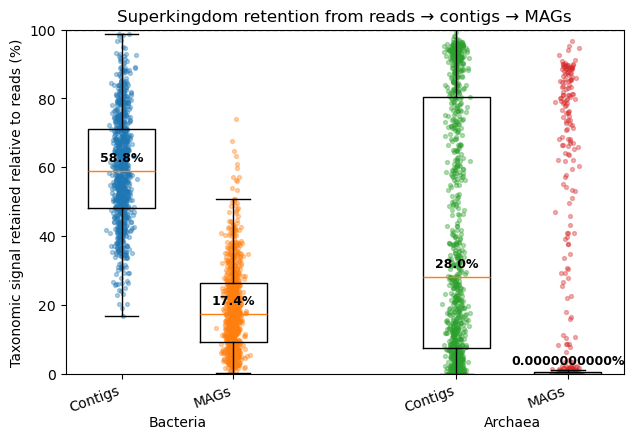

In [11]:
ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
SAMPLE_LIST = os.path.join(ROOT, "SAMPLE-LIST.BIG.txt")

TAX_DIR = os.path.join(ROOT, "outputs", "tax")
RANK = "superkingdom"
TAXA_KEEP = ["d__Bacteria", "d__Archaea"]

OUTFIG = "fig_superkingdom_retention.png"
SEED = 0
# -------------------------

def extract_nodes_by_rank_and_name(tree):
    """Flatten a taxburst tree into:
      - nodes_by_rank[rank] -> list of nodes
      - nodes_by_name[name] -> node
    """
    nodes = taxburst.checks.collect_all_nodes(tree)
    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}
    for node in nodes:
        rank = node.get("rank")
        name = node.get("name")
        if rank is None or name is None:
            continue
        nodes_by_rank[rank].append(node)
        # within a tree, names should be unique (per Titus)
        if name in nodes_by_name:
            # If you ever hit this, keep the first and ignore duplicates.
            continue
        nodes_by_name[name] = node
    return nodes_by_rank, nodes_by_name


def load_tree(path):
    with open(path, "r") as fp:
        return json.load(fp)


def main():
    # Load samples
    with open(SAMPLE_LIST) as fp:
        samples = [x.strip() for x in fp if x.strip()]
    print(f"Loaded {len(samples)} samples from {SAMPLE_LIST}")

    rows = []
    missing = 0

    for i, sample in enumerate(samples):
        if i % 50 == 0:
            print(f"... {i} / {len(samples)}")

        reads_path = os.path.join(TAX_DIR, f"{sample}.reads.gather.json")
        contigs_path = os.path.join(TAX_DIR, f"{sample}.contigs.gather.json")
        bins_path = os.path.join(TAX_DIR, f"{sample}.bins.gather.json")

        if not (os.path.exists(reads_path) and os.path.exists(contigs_path) and os.path.exists(bins_path)):
            missing += 1
            continue

        read_tree = load_tree(reads_path)
        contig_tree = load_tree(contigs_path)
        bin_tree = load_tree(bins_path)

        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)

        # Iterate over superkingdom nodes in reads (baseline)
        for read_node in read_by_rank.get(RANK, []):
            name = read_node.get("name")
            if name in (None, "unclassified"):
                continue
            if name not in TAXA_KEEP:
                continue

            read_count = float(read_node.get("count", 0.0))
            if read_count <= 0:
                continue

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = float(contig_node.get("count", 0.0)) if contig_node else 0.0
            bin_count = float(bin_node.get("count", 0.0)) if bin_node else 0.0

            rows.append(
                dict(
                    sample=sample,
                    taxon=name,
                    read_count=read_count,
                    contig_count=contig_count,
                    bin_count=bin_count,
                    contig_p=contig_count / read_count * 100.0,
                    bin_p=bin_count / read_count * 100.0,
                )
            )

    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit("No data loaded. Check ROOT/TAX_DIR/SAMPLE_LIST paths and filenames.")

    print(f"Built table: {df.shape[0]} rows across {df['sample'].nunique()} samples. Missing samples skipped: {missing}")

    # -------------------------
    # Plot: boxplot + jitter
    # -------------------------
    taxa = ["d__Bacteria", "d__Archaea"]
    stages = [("Contigs", "contig_p"), ("MAGs", "bin_p")]

    data = []
    labels = []
    positions = []
    pos = 1
    gap = 1

    for t in taxa:
        for stage_label, col in stages:
            vals = df.loc[df.taxon == t, col].astype(float).to_numpy()
            data.append(vals)
            labels.append(stage_label)
            positions.append(pos)
            pos += 1
        pos += gap  # visual gap between taxa groups

    rng = np.random.default_rng(SEED)

    plt.figure(figsize=(6.5, 4.5))
    plt.boxplot(data, positions=positions, widths=0.6, patch_artist=False, showfliers=False)

    # Jittered per-sample points
    for i, vals in enumerate(data):
        x0 = positions[i]
        x_jitter = np.random.normal(x0, 0.04, size=len(vals))
        plt.scatter(x_jitter, vals, s=8, alpha=0.35)

    # -------------------------
    # Median annotations
    # -------------------------
    for i, vals in enumerate(data):
        med = np.median(vals)
        x = positions[i]
        if med >= 1:
            label = f"{med:.1f}%"
        else:
            label = f"{med:.10f}%"
        plt.text(x,med + 2,label,ha="center",va="bottom",fontsize=9,fontweight="bold",color="black")

    plt.axhline(100, linestyle="--", color="gray", linewidth=1)
    plt.xticks(positions, labels, rotation=20, ha="right")
    plt.ylabel("Taxonomic signal retained relative to reads (%)")
    plt.ylim(0, 100)
    plt.title("Superkingdom retention from reads → contigs → MAGs")

    # Group labels under the x-axis
    group_centers = [(positions[0] + positions[1]) / 2, (positions[2] + positions[3]) / 2]
    for center, name in zip(group_centers, ["Bacteria", "Archaea"]):
        plt.text(center, -12, name, ha="center", va="top")
    
    plt.tight_layout()
    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")
    print(f"Wrote {OUTFIG}")

if __name__ == "__main__":
    main()

Loaded 915 samples
... 0/915
... 50/915
... 100/915
... 150/915
... 200/915
... 250/915
... 300/915
... 350/915
... 400/915
... 450/915
... 500/915
... 550/915
... 600/915
... 650/915
... 700/915
... 750/915
... 800/915
... 850/915
... 900/915
Rows: 1794
Samples: 897
Missing samples: 18

Preview:
       sample        taxon   contig_p      bin_p
0  ERR1135212  d__Bacteria  61.516841  16.748350
1  ERR1135212   d__Archaea  28.163587   0.000000
2  ERR1135219  d__Bacteria  60.674233  15.413304
3  ERR1135219   d__Archaea  33.289037   0.000000
4  ERR1135259  d__Bacteria  60.010089  13.508536
Wrote superkingdom_retention.tsv
Wrote Superkingdom_violin.png


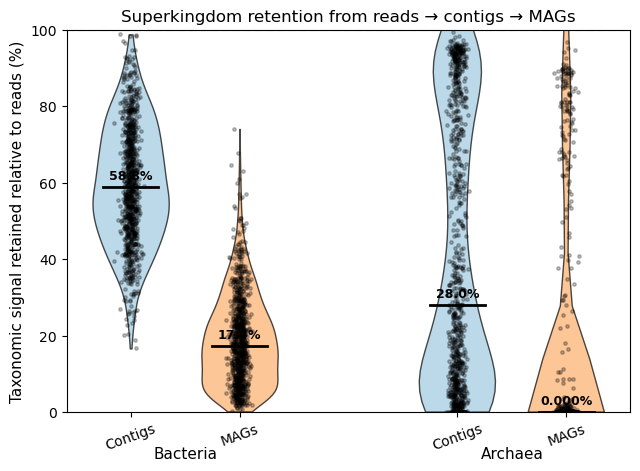

In [19]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import taxburst

# -------------------------
# Paths
# -------------------------

ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
SAMPLE_LIST = os.path.join(ROOT, "SAMPLE-LIST.BIG.txt")

TAX_DIR = os.path.join(ROOT, "outputs", "tax")

RANK = "superkingdom"
TAXA_KEEP = ["d__Bacteria", "d__Archaea"]

OUTDATA = "superkingdom_retention.tsv"
OUTFIG = "Superkingdom_violin.png"

SEED = 0


# -------------------------
# Helpers
# -------------------------

def extract_nodes_by_rank_and_name(tree):

    nodes = taxburst.checks.collect_all_nodes(tree)

    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}

    for node in nodes:

        rank = node.get("rank")
        name = node.get("name")

        if rank is None or name is None:
            continue

        nodes_by_rank[rank].append(node)

        if name not in nodes_by_name:
            nodes_by_name[name] = node

    return nodes_by_rank, nodes_by_name


def load_tree(path):

    with open(path) as fp:
        return json.load(fp)


# -------------------------
# Build dataframe
# -------------------------

def build_table():

    with open(SAMPLE_LIST) as fp:
        samples = [x.strip() for x in fp if x.strip()]

    print(f"Loaded {len(samples)} samples")

    rows = []
    missing = 0

    for i, sample in enumerate(samples):

        if i % 50 == 0:
            print(f"... {i}/{len(samples)}")

        reads_path = os.path.join(TAX_DIR, f"{sample}.reads.gather.json")
        contigs_path = os.path.join(TAX_DIR, f"{sample}.contigs.gather.json")
        bins_path = os.path.join(TAX_DIR, f"{sample}.bins.gather.json")

        if not (os.path.exists(reads_path)
                and os.path.exists(contigs_path)
                and os.path.exists(bins_path)):

            missing += 1
            continue

        read_tree = load_tree(reads_path)
        contig_tree = load_tree(contigs_path)
        bin_tree = load_tree(bins_path)

        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)

        for read_node in read_by_rank.get(RANK, []):

            name = read_node.get("name")

            if name in (None, "unclassified"):
                continue

            if name not in TAXA_KEEP:
                continue

            read_count = float(read_node.get("count", 0))

            if read_count <= 0:
                continue

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = float(contig_node.get("count", 0)) if contig_node else 0
            bin_count = float(bin_node.get("count", 0)) if bin_node else 0

            rows.append(dict(
                sample=sample,
                taxon=name,
                contig_p=contig_count / read_count * 100,
                bin_p=bin_count / read_count * 100
            ))

    df = pd.DataFrame(rows)

    print("Rows:", df.shape[0])
    print("Samples:", df["sample"].nunique())
    print("Missing samples:", missing)

    print("\nPreview:")
    print(df.head())

    df.to_csv(OUTDATA, sep="\t", index=False)

    print(f"Wrote {OUTDATA}")

    return df


# -------------------------
# Plot violin
# -------------------------

def plot_violin(df):

    taxa = ["d__Bacteria", "d__Archaea"]
    stages = [("Contigs", "contig_p"), ("MAGs", "bin_p")]

    data = []
    labels = []
    positions = []
    colors = []

    pos = 1
    gap = 1

    for t in taxa:

        for stage_label, col in stages:

            vals = df.loc[df.taxon == t, col].astype(float).to_numpy()

            data.append(vals)
            labels.append(stage_label)
            positions.append(pos)

            if stage_label == "Contigs":
                colors.append("#9ecae1")
            else:
                colors.append("#fdae6b")

            pos += 1

        pos += gap

    rng = np.random.default_rng(SEED)

    plt.figure(figsize=(6.5, 4.8))

    parts = plt.violinplot(
        data,
        positions=positions,
        widths=0.7,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_edgecolor("black")
        pc.set_alpha(0.7)

    # median lines
    for i, vals in enumerate(data):

        med = np.median(vals)
        x = positions[i]

        plt.plot([x - 0.25, x + 0.25], [med, med],
                 color="black", linewidth=2)

        label = f"{med:.1f}%" if med >= 1 else f"{med:.3f}%"

        plt.text(x, med + 2, label,
                 ha="center",
                 fontsize=9,
                 fontweight="bold")

    # jitter points
    for i, vals in enumerate(data):

        x0 = positions[i]
        x_jitter = rng.normal(x0, 0.04, len(vals))

        plt.scatter(
            x_jitter,
            vals,
            s=6,
            alpha=0.25,
            color="black"
        )

    plt.axhline(100, linestyle="--", color="gray")

    plt.xticks(positions, labels, rotation=20)

    plt.ylabel("Taxonomic signal retained relative to reads (%)", fontsize=11)

    plt.ylim(0, 100)

    plt.title("Superkingdom retention from reads → contigs → MAGs")

    group_centers = [
        (positions[0] + positions[1]) / 2,
        (positions[2] + positions[3]) / 2
    ]

    for center, name in zip(group_centers, ["Bacteria", "Archaea"]):

        plt.text(center, -12, name, ha="center", fontsize=11)

    plt.tight_layout()

    plt.savefig(OUTFIG, dpi=400, bbox_inches="tight")

    print(f"Wrote {OUTFIG}")


# -------------------------
# Main
# -------------------------

def main():

    df = build_table()

    plot_violin(df)


if __name__ == "__main__":
    main()

Saved: SK_violin_pastel.png


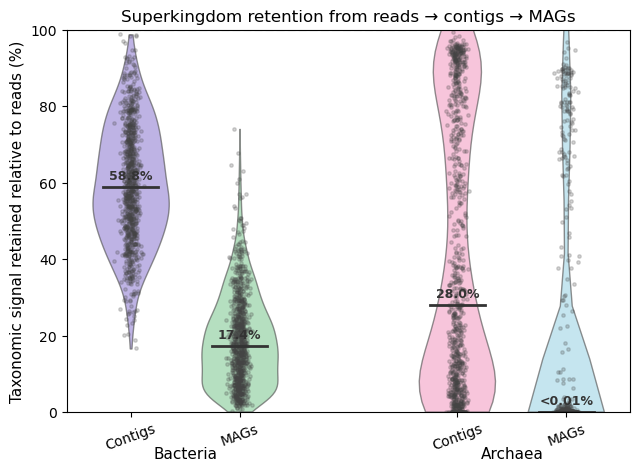

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = "superkingdom_retention.tsv"
OUTFIG = "SK_violin_pastel.png"

SEED = 0

df = pd.read_csv(DATA, sep="\t")

taxa = ["d__Bacteria", "d__Archaea"]
stages = [("Contigs","contig_p"),("MAGs","bin_p")]

data = []
labels = []
positions = []
colors = []

pos = 1
gap = 1

for t in taxa:

    for stage_label, col in stages:

        vals = df.loc[df.taxon == t, col].astype(float).to_numpy()

        data.append(vals)
        labels.append(stage_label)
        positions.append(pos)

        # Pastel color palette
        if t == "d__Bacteria" and stage_label == "Contigs":
            colors.append("#9B8AD6")   # pastel purple
        elif t == "d__Bacteria" and stage_label == "MAGs":
            colors.append("#8ECF9E")   # pastel green
        elif t == "d__Archaea" and stage_label == "Contigs":
            colors.append("#F3A6C8")   # pastel pink
        else:
            colors.append("#A6D7E7")   # pastel light blue

        pos += 1

    pos += gap


rng = np.random.default_rng(SEED)

plt.figure(figsize=(6.5,4.8))

parts = plt.violinplot(
    data,
    positions=positions,
    widths=0.7,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Apply colors
for pc,color in zip(parts["bodies"],colors):

    pc.set_facecolor(color)
    pc.set_edgecolor("#555555")
    pc.set_alpha(0.65)


# Median lines
for i,vals in enumerate(data):

    med = np.median(vals)
    x = positions[i]

    plt.plot(
        [x-0.25,x+0.25],
        [med,med],
        color="#333333",
        linewidth=2
    )

    if med < 0.01:
        label = "<0.01%"
    elif med < 1:
        label = f"{med:.2f}%"
    else:
        label = f"{med:.1f}%"

    plt.text(
        x,
        med+2,
        label,
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )


# Jittered points
for i,vals in enumerate(data):

    x0 = positions[i]
    x_jitter = rng.normal(x0,0.04,len(vals))

    plt.scatter(
        x_jitter,
        vals,
        s=6,
        alpha=0.22,
        color="#444444"
    )


plt.axhline(100,linestyle="--",color="#999999")

plt.xticks(positions,labels,rotation=20)

plt.ylabel("Taxonomic signal retained relative to reads (%)",fontsize=11)

plt.ylim(0,100)

plt.title("Superkingdom retention from reads → contigs → MAGs")


group_centers = [
    (positions[0]+positions[1])/2,
    (positions[2]+positions[3])/2
]

for center,name in zip(group_centers,["Bacteria","Archaea"]):
    plt.text(center,-12,name,ha="center",fontsize=11)


plt.tight_layout()

plt.savefig(OUTFIG,dpi=400,bbox_inches="tight")

print("Saved:",OUTFIG)